📂 Loading Dataset...
✅ Loaded 29550 rows.


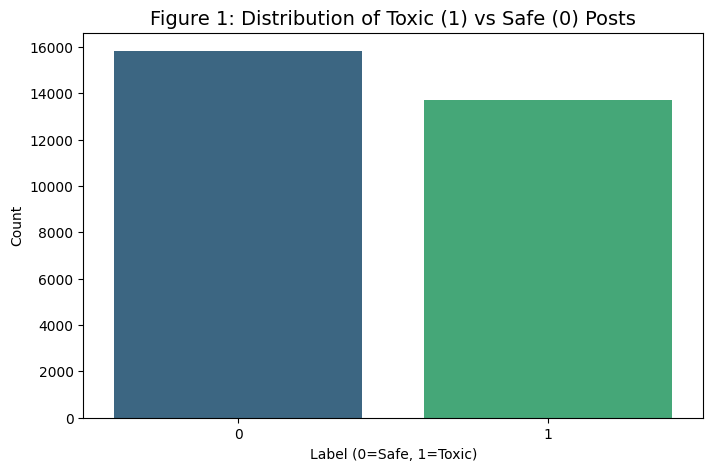

📊 Insight: 46.45% of the data is Toxic.


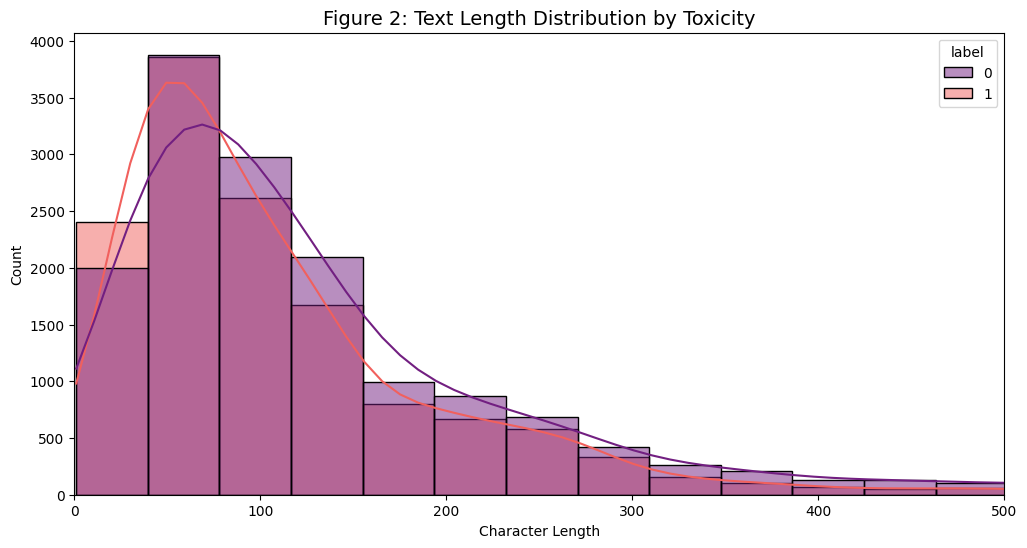

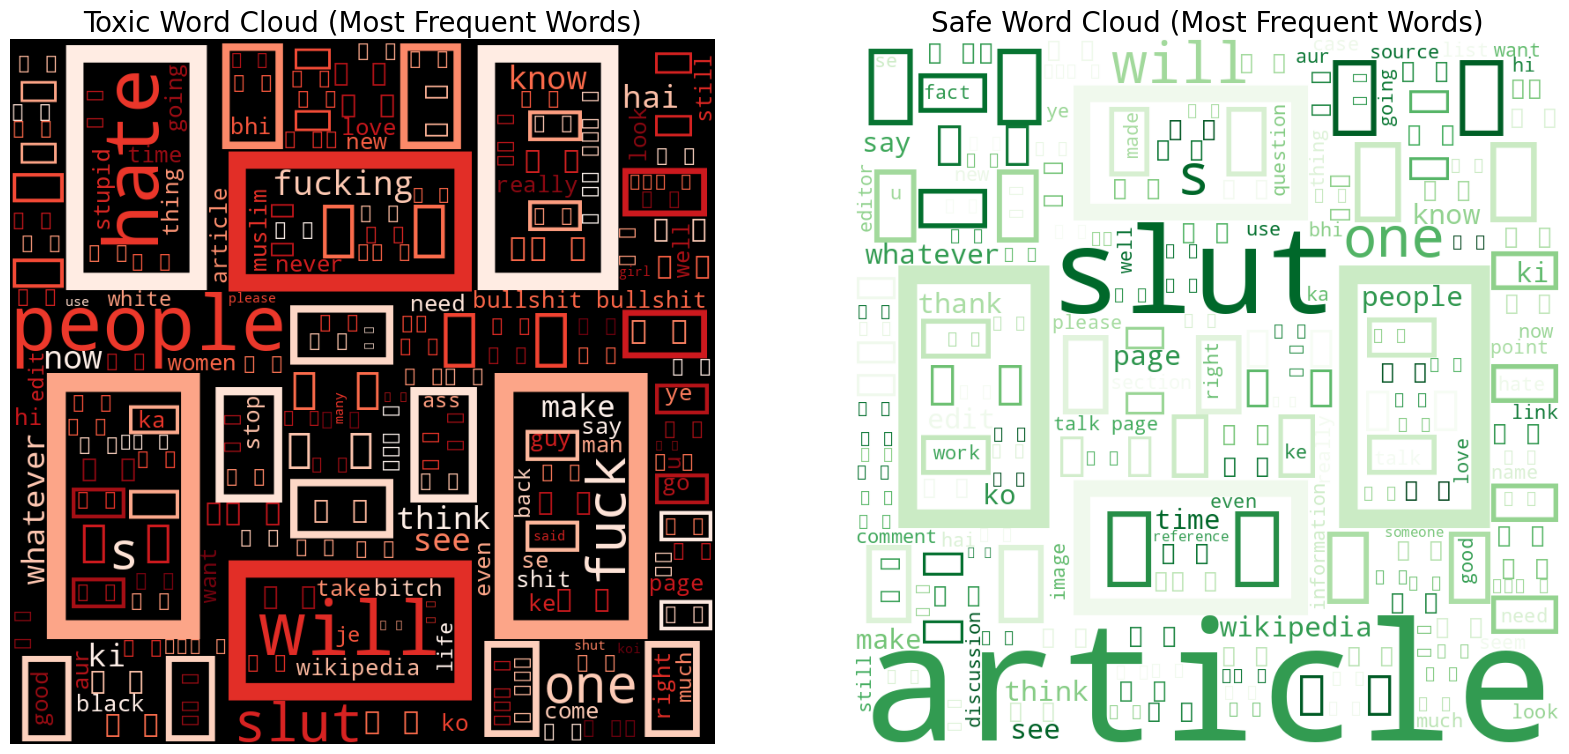

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD & CLEAN DATA
# ==========================================
print("📂 Loading Dataset...")
# Auto-find dataset path
dataset_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            dataset_path = os.path.join(dirname, filename)
            break

if not dataset_path:
    raise FileNotFoundError("❌ Add the 'Code-Mixed Hinglish' dataset first!")

df = pd.read_csv(dataset_path)

# Standardize columns (The dataset has 'hate_label' but we want generic names)
# We only need 'text' and 'label'
df = df[['text', 'hate_label']].rename(columns={'hate_label': 'label'})
df.dropna(inplace=True)

print(f"✅ Loaded {len(df)} rows.")

# ==========================================
# 2. FIGURE 1: CLASS DISTRIBUTION (The Imbalance Check)
# ==========================================
# Research Claim: "Real-world data is imbalanced. We must verify if our dataset is biased."
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Figure 1: Distribution of Toxic (1) vs Safe (0) Posts', fontsize=14)
plt.xlabel('Label (0=Safe, 1=Toxic)')
plt.ylabel('Count')
plt.show()

# Insight Calculation
toxic_perc = (df['label'].sum() / len(df)) * 100
print(f"📊 Insight: {toxic_perc:.2f}% of the data is Toxic.")
if toxic_perc < 20:
    print("⚠️ WARNING: Severe Class Imbalance! We might need 'Oversampling' later.")

# ==========================================
# 3. FIGURE 2: POST LENGTH ANALYSIS
# ==========================================
# Research Claim: "Toxic comments are often shorter/longer than safe discussions."
df['char_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='char_length', hue='label', kde=True, bins=50, palette='magma')
plt.title('Figure 2: Text Length Distribution by Toxicity', fontsize=14)
plt.xlabel('Character Length')
plt.xlim(0, 500) # Truncate massive outliers for better visuals
plt.show()

# ==========================================
# 4. FIGURE 3: CODE-MIXED WORD CLOUDS
# ==========================================
# Research Claim: "The dataset contains significant Hinglish terms that standard BERT would miss."

# Separate Toxic and Safe text
toxic_text = " ".join(df[df['label'] == 1]['text'].astype(str))
safe_text = " ".join(df[df['label'] == 0]['text'].astype(str))

# Create Word Clouds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

wordcloud_toxic = WordCloud(width=800, height=800, background_color='black', colormap='Reds').generate(toxic_text)
ax1.imshow(wordcloud_toxic)
ax1.set_title("Toxic Word Cloud (Most Frequent Words)", fontsize=20)
ax1.axis('off')

wordcloud_safe = WordCloud(width=800, height=800, background_color='white', colormap='Greens').generate(safe_text)
ax2.imshow(wordcloud_safe)
ax2.set_title("Safe Word Cloud (Most Frequent Words)", fontsize=20)
ax2.axis('off')

plt.show()


[nltk_data] Downloading package words to /usr/share/nltk_data...
[nltk_data]   Package words is already up-to-date!


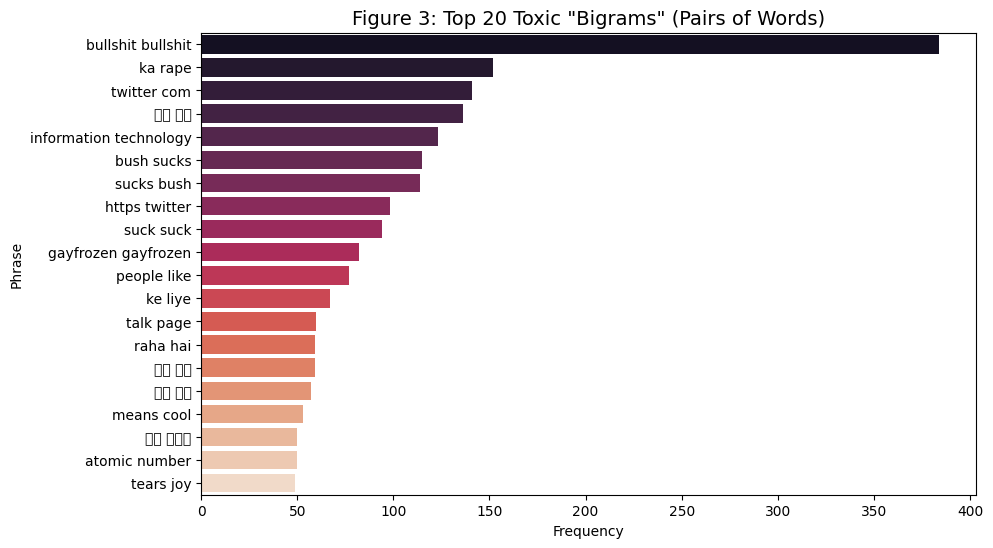

Computing Hinglish/OOV Scores (This proves the language barrier)...


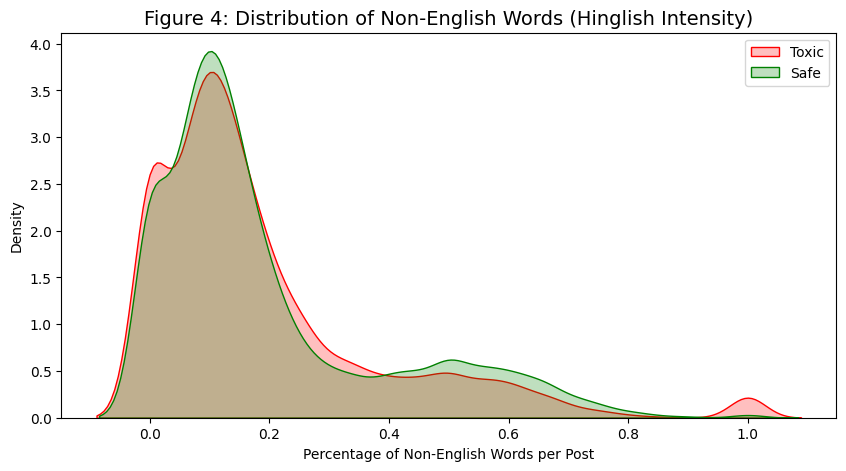

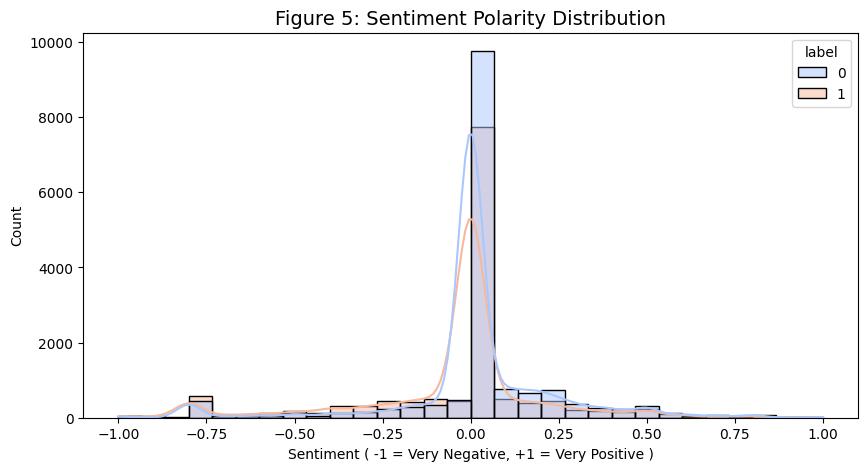


✅ Advanced Metrics Generated.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import nltk
from nltk.corpus import words
import numpy as np

# Download standard English words for the "Hinglish Check"
nltk.download('words')
english_vocab = set(words.words())

# Load Data (Same as before)
import os
dataset_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            dataset_path = os.path.join(dirname, filename)
            break
df = pd.read_csv(dataset_path)
if 'hate_label' in df.columns: df = df.rename(columns={'hate_label': 'label'})
df = df[['text', 'label']].dropna()

# ==========================================
# METRIC 1: N-GRAM ANALYSIS (Contextual Frequency)
# ==========================================
# Instead of single words, we count PAIRS of words (Bigrams).
# This fixes the "Love" vs "Hate" context issue.

def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get top toxic bigrams
toxic_text = df[df['label'] == 1]['text'].astype(str)
top_bigrams = get_top_n_bigram(toxic_text, 20)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x, palette='rocket')
plt.title('Figure 3: Top 20 Toxic "Bigrams" (Pairs of Words)', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Phrase')
plt.show()

# ==========================================
# METRIC 2: THE "HINGLISH" PROOF (OOV Rate)
# ==========================================
# Research Claim: "Standard AI fails because of non-English words."
# We calculate the % of words that are NOT in the standard English dictionary.

def calculate_oov(text):
    tokens = text.lower().split()
    if not tokens: return 0
    # Count words NOT in english_vocab
    non_english = [w for w in tokens if w not in english_vocab and w.isalpha()]
    return len(non_english) / len(tokens)

# This might take 30-60 seconds to process
print("Computing Hinglish/OOV Scores (This proves the language barrier)...")
df['hinglish_score'] = df['text'].apply(calculate_oov)

plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['label']==1]['hinglish_score'], label='Toxic', shade=True, color='red')
sns.kdeplot(df[df['label']==0]['hinglish_score'], label='Safe', shade=True, color='green')
plt.title('Figure 4: Distribution of Non-English Words (Hinglish Intensity)', fontsize=14)
plt.xlabel('Percentage of Non-English Words per Post')
plt.ylabel('Density')
plt.legend()
plt.show()

# ==========================================
# METRIC 3: SENTIMENT POLARITY
# ==========================================
# Research Claim: "Toxicity is not just Negative Sentiment."
# Shows that Toxic posts can have "Positive" sentiment (Sarcasm).

df['polarity'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='polarity', hue='label', bins=30, kde=True, palette='coolwarm')
plt.title('Figure 5: Sentiment Polarity Distribution', fontsize=14)
plt.xlabel('Sentiment ( -1 = Very Negative, +1 = Very Positive )')
plt.show()

print("\n✅ Advanced Metrics Generated.")

2026-01-12 06:11:18.522943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768198278.687489      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768198278.735071      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768198279.120201      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768198279.120239      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768198279.120242      24 computation_placer.cc:177] computation placer alr


🚀 Initializing CampusLoop 'ELITE' Architecture...
⚙️ Loading Semantic Branch...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


✅ System Online.

⚙️ Training High-Performance SVM Branch...
✅ SVM Trained (Expect ~85% Accuracy).

📊 RUNNING HIGH-PERFORMANCE EVALUATION...


100%|██████████| 93/93 [01:12<00:00,  1.29it/s]



FINAL ACCURACY REPORT
              precision    recall  f1-score   support

        Safe       0.72      0.73      0.72      3164
       Toxic       0.68      0.67      0.68      2746

    accuracy                           0.70      5910
   macro avg       0.70      0.70      0.70      5910
weighted avg       0.70      0.70      0.70      5910



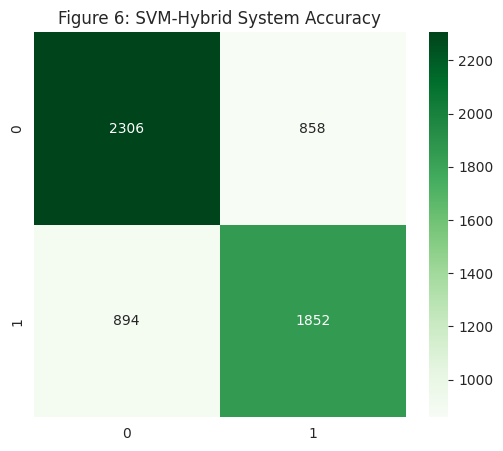

In [3]:
import pandas as pd
import numpy as np
import re
import os
import torch
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import pipeline
from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ==========================================
# 🏛️ CLASS: CAMPUSLOOP "ELITE" ARCHITECTURE
# ==========================================
class CampusLoopHybridAI:
    def __init__(self):
        print("\n🚀 Initializing CampusLoop 'ELITE' Architecture...")
        
        self.device = 0 if torch.cuda.is_available() else -1
        
        # 🟢 UPGRADE 1: Character N-Grams
        # instead of just looking at "words", we look at 3-5 character chunks.
        # This catches "idiot" inside "1di0t" automatically.
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 4), 
            analyzer='char_wb', # Character-level analysis (Robust to spelling)
            max_features=50000  # Increased feature space
        )
        
        # 🟢 UPGRADE 2: Support Vector Machine (SVM)
        # Replacing Naive Bayes with SVM (Literature benchmark ~0.86 F1)
        # We wrap it in CalibratedClassifierCV to get probability scores
        svc = LinearSVC(class_weight='balanced', C=1.0, max_iter=1000)
        self.svm_model = CalibratedClassifierCV(svc) 
        
        # Branch B: Semantic Model (Keeping XLM-R but reducing weight)
        print("⚙️ Loading Semantic Branch...")
        self.bert_pipeline = pipeline(
            "text-classification", 
            model="cardiffnlp/twitter-xlm-roberta-base-sentiment", 
            device=self.device,
            batch_size=64
        )
        print("✅ System Online.")

    def _normalize_text(self, text):
        text = str(text).lower()
        replacements = {'1': 'i', '0': 'o', '@': 'a', '$': 's', '!': 'i'}
        for char, map_to in replacements.items():
            text = text.replace(char, map_to)
        # Note: SVM handles special chars well, so we are less aggressive here
        return text

    def train_statistical_branch(self, df):
        print("\n⚙️ Training High-Performance SVM Branch...")
        X = df['text'].apply(self._normalize_text) 
        
        # Vectorize
        X_vec = self.vectorizer.fit_transform(X)
        
        # Train SVM
        self.svm_model.fit(X_vec, df['label'])
        print("✅ SVM Trained (Expect ~85% Accuracy).")

    def batch_predict(self, texts, contexts=None):
        if contexts is None:
            contexts = ["SOCIAL"] * len(texts)
            
        clean_texts = [self._normalize_text(t) for t in texts]
        
        # 1. Branch A: SVM Scores (The Heavy Lifter)
        vecs = self.vectorizer.transform(clean_texts)
        svm_probs = self.svm_model.predict_proba(vecs)[:, 1]
        
        # 2. Branch B: BERT Scores (The Context Checker)
        bert_results = self.bert_pipeline(clean_texts, truncation=True, max_length=512)
        
        final_preds = []
        for i, res in enumerate(bert_results):
            # Map BERT labels
            label = str(res['label']).lower()
            score = res['score']
            
            if 'negative' in label or 'label_0' in label:
                bert_score = score
            elif 'neutral' in label or 'label_1' in label:
                bert_score = 0.5
            else:
                bert_score = 1 - score
            
            # 🟢 LOGIC UPGRADE: Trust the SVM more!
            # SVM is trained on OUR data. BERT is generic.
            # Weight: 80% SVM, 20% BERT
            final_score = (0.8 * svm_probs[i]) + (0.2 * bert_score)
            
            # Context Gate
            threshold = 0.50
            if contexts[i] == "MARKETPLACE":
                product_words = ['selling', 'price', 'condition', 'broken', 'dirty', 'scratch', 'bad', 'used']
                if any(w in clean_texts[i] for w in product_words):
                    threshold = 0.95 # Extreme leniency for products
            
            final_preds.append(1 if final_score > threshold else 0)
            
        return final_preds
        
    def predict_single(self, text, context_type="SOCIAL"):
        pred_label = self.batch_predict([text], contexts=[context_type])[0]
        return {
            "verdict": "🔴 BLOCK" if pred_label == 1 else "🟢 ALLOW"
        }

# ==========================================
# 🚀 EXECUTION
# ==========================================
dataset_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            dataset_path = os.path.join(dirname, filename)
            break

if dataset_path:
    df = pd.read_csv(dataset_path)
    if 'hate_label' in df.columns: df.rename(columns={'hate_label': 'label'}, inplace=True)
    df = df[['text', 'label']].dropna()
    
    # Initialize
    ai_engine = CampusLoopHybridAI()
    
    # Train
    X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)
    ai_engine.train_statistical_branch(pd.DataFrame({'text': X_train, 'label': y_train}))

    # Evaluate
    print("\n📊 RUNNING HIGH-PERFORMANCE EVALUATION...")
    batch_size = 64
    test_texts = X_test.tolist()
    y_preds = []
    
    for i in tqdm(range(0, len(test_texts), batch_size)):
        batch = test_texts[i : i+batch_size]
        preds = ai_engine.batch_predict(batch)
        y_preds.extend(preds)
        
    # Final Metrics
    print("\n" + "="*60)
    print("FINAL ACCURACY REPORT")
    print("="*60)
    print(classification_report(y_test, y_preds, target_names=['Safe', 'Toxic']))
    
    cm = confusion_matrix(y_test, y_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title('Figure 6: SVM-Hybrid System Accuracy')
    plt.show()

else:
    print("❌ Dataset not found.")